Dataset Shape: (200, 6)

First 5 rows:
   size_sqft  bedrooms  age_years  distance_city  crime_rate  price_lakhs
0       1360         4         30       3.460294    0.200712    92.833901
1       1794         4         19      29.612548    3.220792    54.671087
2       1630         2         17      11.853853    2.114480    98.687373
3       1595         3         19      11.748622    3.274974    85.186387
4       2138         1         28      24.571187    1.197621    73.650840

Statistics:
       size_sqft  bedrooms  age_years  distance_city  crime_rate  price_lakhs
count     200.00    200.00     200.00         200.00      200.00       200.00
mean     2064.93      2.90      25.40          15.68        4.98        89.80
std       819.16      1.39      13.69           8.74        2.80        37.85
min       521.00      1.00       1.00           1.33        0.05        -2.05
25%      1435.75      2.00      13.00           8.01        2.51        63.98
50%      2017.50      3.00      26.0

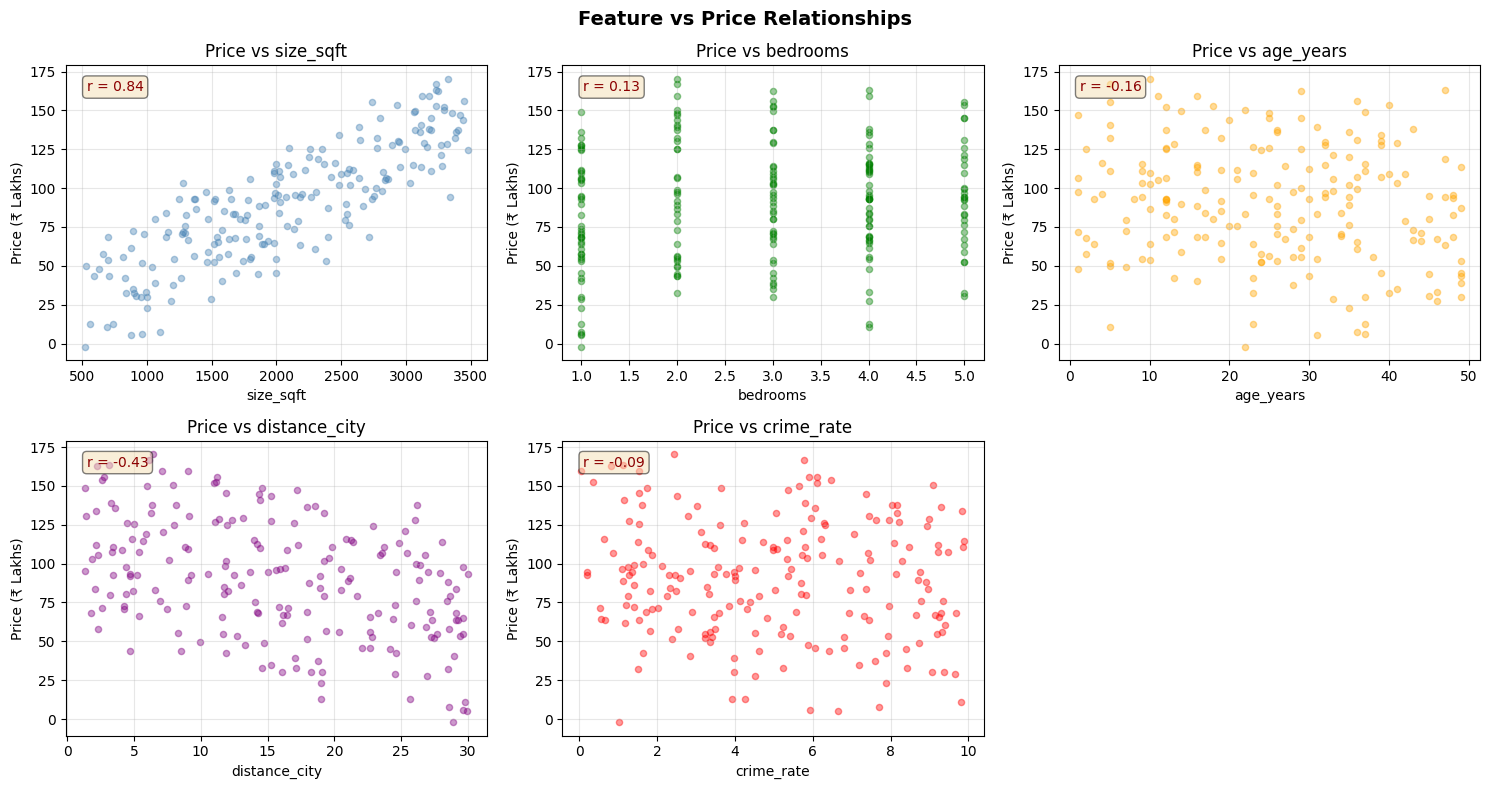


Feature Correlation Matrix:
               size_sqft  bedrooms  age_years  distance_city  crime_rate
size_sqft           1.00      0.02       0.03           0.03        0.04
bedrooms            0.02      1.00       0.08           0.01       -0.00
age_years           0.03      0.08       1.00          -0.01        0.15
distance_city       0.03      0.01      -0.01           1.00       -0.03
crime_rate          0.04     -0.00       0.15          -0.03        1.00

Train size: 160, Test size: 40

── Train Metrics ──
  MAE:  3.69 lakhs
  RMSE: 4.61 lakhs
  R²:   0.9856

── Test Metrics ──
  MAE:  3.96 lakhs
  RMSE: 5.31 lakhs
  R²:   0.9763

Overfit check → Train R²: 0.9856, Test R²: 0.9763
✓ Good generalization — small train/test gap

── Learned Coefficients (on scaled features) ──
      Feature  Coefficient  Abs_Importance
    size_sqft    32.853057       32.853057
distance_city   -16.938034       16.938034
    age_years    -6.611850        6.611850
     bedrooms     4.701279        4.7

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


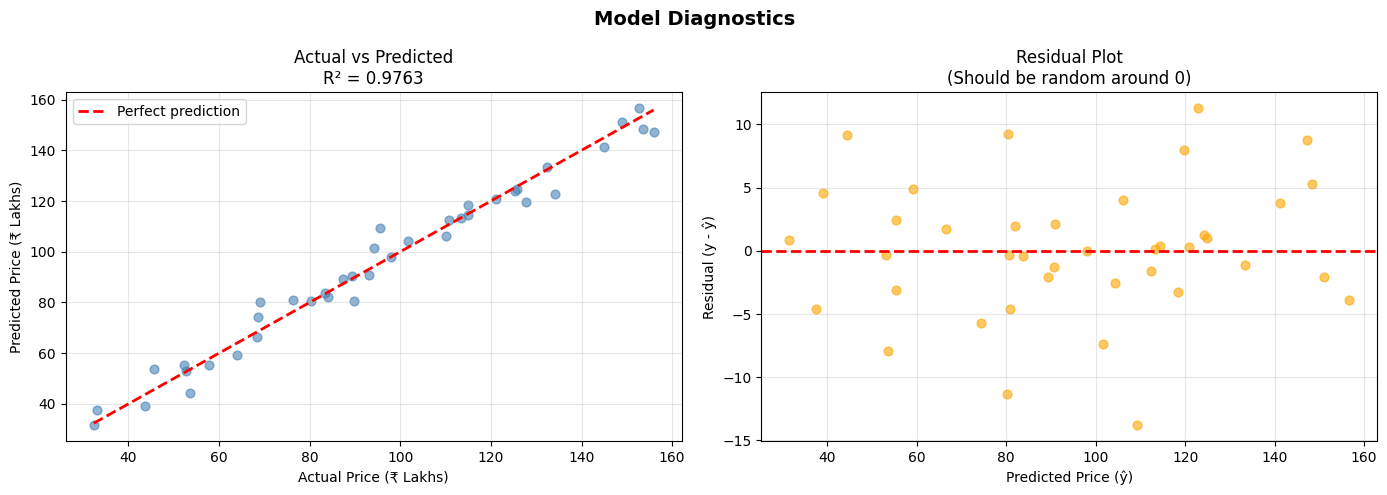

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ─── Step 1: Create Realistic Dataset ────────────────────────────
np.random.seed(42)
n = 200

# Features
size_sqft     = np.random.randint(500, 3500, n)       # House size
bedrooms      = np.random.randint(1, 6, n)            # Bedrooms
age_years     = np.random.randint(1, 50, n)           # House age
distance_city = np.random.uniform(1, 30, n)           # km from city center
crime_rate    = np.random.uniform(0, 10, n)           # Crime index

# Target: Price (₹ in lakhs) — constructed with known relationships
price = (
    50                          # Base price
    + 0.04  * size_sqft         # Bigger = more expensive
    + 3.0   * bedrooms          # More bedrooms = pricier
    - 0.5   * age_years         # Older = cheaper
    - 2.0   * distance_city     # Further from city = cheaper
    - 1.5   * crime_rate        # Higher crime = cheaper
    + np.random.normal(0, 5, n) # Noise
)

# Build DataFrame
df = pd.DataFrame({
    'size_sqft': size_sqft,
    'bedrooms': bedrooms,
    'age_years': age_years,
    'distance_city': distance_city,
    'crime_rate': crime_rate,
    'price_lakhs': price
})

print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nStatistics:")
print(df.describe().round(2))

# ─── Step 2: Exploratory Analysis ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['size_sqft', 'bedrooms', 'age_years', 'distance_city', 'crime_rate']
colors = ['steelblue', 'green', 'orange', 'purple', 'red']

for idx, (feat, col) in enumerate(zip(features, colors)):
    ax = axes[idx // 3][idx % 3]
    ax.scatter(df[feat], df['price_lakhs'], alpha=0.4, color=col, s=20)
    ax.set_xlabel(feat)
    ax.set_ylabel("Price (₹ Lakhs)")
    ax.set_title(f"Price vs {feat}")
    ax.grid(True, alpha=0.3)

    # Add correlation coefficient
    corr = df[feat].corr(df['price_lakhs'])
    ax.text(0.05, 0.95, f"r = {corr:.2f}", transform=ax.transAxes,
            fontsize=10, color='darkred', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1][2].axis('off')  # Hide last unused subplot
plt.suptitle("Feature vs Price Relationships", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── Step 3: Prepare Features ────────────────────────────────────
features = ['size_sqft', 'bedrooms', 'age_years', 'distance_city', 'crime_rate']
X = df[features].values
y = df['price_lakhs'].values

# Check correlation between features (multicollinearity check)
print("\nFeature Correlation Matrix:")
print(df[features].corr().round(2))

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

# Feature scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# ─── Step 4: Train Model ─────────────────────────────────────────
model = LinearRegression()
model.fit(X_train_sc, y_train)

# ─── Step 5: Evaluate ────────────────────────────────────────────
y_pred_train = model.predict(X_train_sc)
y_pred_test  = model.predict(X_test_sc)

def evaluate(y_true, y_pred, split_name):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"\n── {split_name} Metrics ──")
    print(f"  MAE:  {mae:.2f} lakhs")
    print(f"  RMSE: {rmse:.2f} lakhs")
    print(f"  R²:   {r2:.4f}")
    return r2

r2_train = evaluate(y_train, y_pred_train, "Train")
r2_test  = evaluate(y_test,  y_pred_test,  "Test")

print(f"\nOverfit check → Train R²: {r2_train:.4f}, Test R²: {r2_test:.4f}")
if r2_train - r2_test > 0.1:
    print("⚠ Possible overfitting! Gap > 0.1")
else:
    print("✓ Good generalization — small train/test gap")

# ─── Step 6: Interpret Coefficients ──────────────────────────────
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_,
    'Abs_Importance': np.abs(model.coef_)
}).sort_values('Abs_Importance', ascending=False)

print("\n── Learned Coefficients (on scaled features) ──")
print(coef_df.to_string(index=False))
print(f"\nIntercept: {model.intercept_:.2f}")
print("\nInterpretation (on scaled data):")
for _, row in coef_df.iterrows():
    direction = "increases" if row['Coefficient'] > 0 else "decreases"
    print(f"  • {row['Feature']}: 1-SD increase {direction} price by {abs(row['Coefficient']):.2f} lakhs")

# ─── Step 7: Cross-Validation ────────────────────────────────────
cv_scores = cross_val_score(model,
                            scaler.fit_transform(X),   # Scale all data
                            y,
                            cv=5,
                            scoring='r2')
print(f"\n── 5-Fold Cross-Validation R² ──")
print(f"  Scores: {cv_scores.round(4)}")
print(f"  Mean:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# ─── Step 8: Prediction on New House ─────────────────────────────
new_house = pd.DataFrame({
    'size_sqft': [2000],
    'bedrooms': [3],
    'age_years': [10],
    'distance_city': [8],
    'crime_rate': [3]
})
new_house_sc = scaler.transform(new_house[features])
predicted_price = model.predict(new_house_sc)[0]
print(f"\n── New House Prediction ──")
print(f"  Features: 2000 sqft, 3 bed, 10 yrs old, 8km from city, crime=3")
print(f"  Predicted price: ₹{predicted_price:.1f} lakhs")

# ─── Step 9: Actual vs Predicted Plot ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Actual vs Predicted
ax1 = axes[0]
ax1.scatter(y_test, y_pred_test, alpha=0.6, color='steelblue', s=40)
perfect_line = [y_test.min(), y_test.max()]
ax1.plot(perfect_line, perfect_line, 'r--', linewidth=2, label='Perfect prediction')
ax1.set_xlabel("Actual Price (₹ Lakhs)")
ax1.set_ylabel("Predicted Price (₹ Lakhs)")
ax1.set_title(f"Actual vs Predicted\nR² = {r2_test:.4f}")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Residual plot
ax2 = axes[1]
residuals = y_test - y_pred_test
ax2.scatter(y_pred_test, residuals, alpha=0.6, color='orange', s=40)
ax2.axhline(y=0, color='red', linewidth=2, linestyle='--')
ax2.set_xlabel("Predicted Price (ŷ)")
ax2.set_ylabel("Residual (y - ŷ)")
ax2.set_title("Residual Plot\n(Should be random around 0)")
ax2.grid(True, alpha=0.3)

plt.suptitle("Model Diagnostics", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()


